In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
import zipfile

zip_path     = '/content/drive/MyDrive/cats-dogs-project/archive.zip'
extract_path = '/content/data'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Done unzipping!")

Done unzipping!


In [ ]:
base     = '/content/drive/MyDrive/cats-dogs-project/data'
cats_dir = '/content/data/PetImages/Cat'
dogs_dir = '/content/data/PetImages/Dog'

def split_and_copy(src_dir, category):
    files = [f for f in os.listdir(src_dir) if f.endswith('.jpg')]
    random.shuffle(files)
    n = len(files)

    splits = {
        'train':      files[:int(0.8 * n)],
        'validation': files[int(0.8 * n):int(0.9 * n)],
        'test':       files[int(0.9 * n):]
    }

    for split, filelist in splits.items():
        os.makedirs(f'{base}/{split}/{category}', exist_ok=True)
        for fname in filelist:
            shutil.copy(
                f'{src_dir}/{fname}',
                f'{base}/{split}/{category}/{fname}'
            )

    print(f'{category} → train: {len(splits["train"])}, '
          f'val: {len(splits["validation"])}, test: {len(splits["test"])}')

already_split = (
    os.path.exists(f'{base}/train/cats') and
    len(os.listdir(f'{base}/train/cats')) > 0
)

if already_split:
    print("Data already split on Drive — skipping.")
else:
    print("Splitting data... (this takes 5–10 minutes)")
    split_and_copy(cats_dir, 'cats')
    split_and_copy(dogs_dir, 'dogs')
    print("Split complete!")


Data already split on Drive — skipping.


In [ ]:
local_base = '/content/local_data'

already_local = (
    os.path.exists(f'{local_base}/train') and
    len(os.listdir(f'{local_base}/train')) > 0
)

if already_local:
    print("Data already copied locally — skipping.")
else:
    print("Copying data from Drive to Colab... (3–5 mins, once per session)")
    shutil.copytree(f'{base}/train',      f'{local_base}/train')
    shutil.copytree(f'{base}/validation', f'{local_base}/validation')
    shutil.copytree(f'{base}/test',       f'{local_base}/test')
    print("Done! Data is now local.")

Copying data from Drive to Colab... (3–5 mins, once per session)
Done! Data is now local.


In [ ]:
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen   = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    f'{local_base}/train',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    f'{local_base}/validation',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    f'{local_base}/test',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

Found 20000 images belonging to 2 classes.
Found 2500 images belonging to 2 classes.
Found 2500 images belonging to 2 classes.


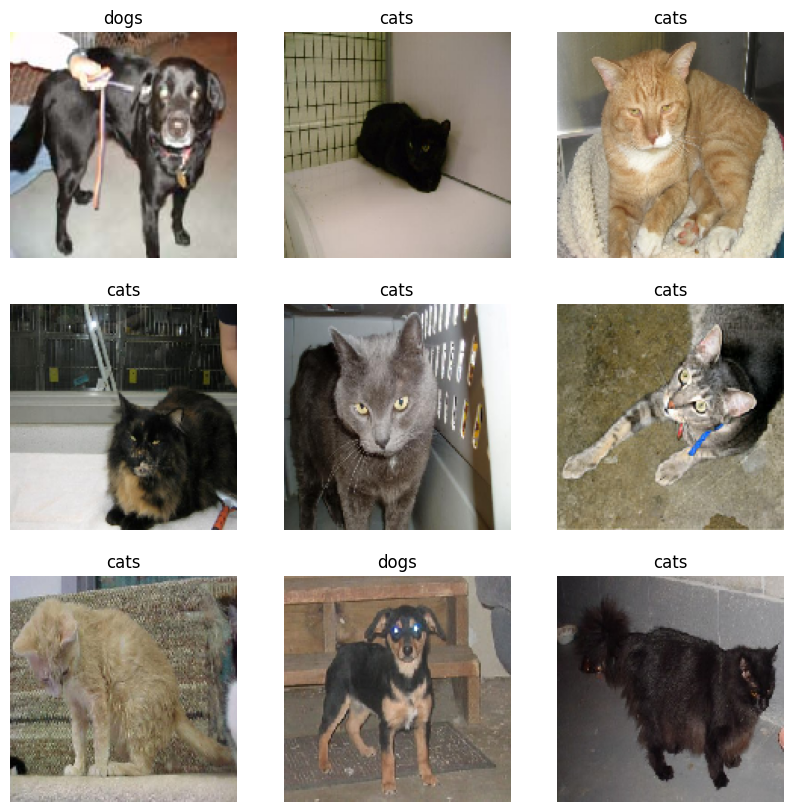

In [ ]:
images, labels = next(train_generator)
class_names = ['cats', 'dogs']

plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title(class_names[int(labels[i])])
    plt.axis('off')
plt.show()


In [ ]:
model_path = '/content/drive/MyDrive/cats-dogs-project/model.keras'

if os.path.exists(model_path):
    model = load_model(model_path)
    print("Model loaded from Drive — skipping training!")
    model_loaded = True
else:
    print("No saved model found — building from scratch...")
    model_loaded = False

    model = models.Sequential([
        layers.Input(shape=(150, 150, 3)),

        # Block 1 — finds basic features like edges and corners
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),

        # Block 2 — finds more complex features like eyes and ears
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),

        # Block 3 — finds high level features like faces and tails
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),

        # Flatten and classify
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.Dense(1, activation='sigmoid')  # 0 = cat, 1 = dog
    ])

    model.summary()



No saved model found — building from scratch...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,034,177 (72.61 MB)

 Trainable params: 19,034,177 (72.61 MB)

 Non-trainable params: 0 (0.00 B)